#Modelagem e Determinação da Constante de Decaimento de DBO em Lagoas de Estabilização Utilizando Algoritmos de Minimização de Erro Quadrático
Trabalho final de matemática instrumental
Equipe: Luana Nascimento Barbosa Souza, Israel Lima, Juliana, Silas Yrion


O presente estudo é originado de uma base de dados real, base que é objeto de estudo da mestranda Luana Souza e tem origem no trabalho de doutorado da professora Dra Karla Esquerre.

**Situação-Problema**
No cenário do gerenciamento ambiental de complexos industriais, o tratamento adequado de águas residuárias é uma exigência legal e ecológica crítica. Lagoas de estabilização são amplamente utilizadas para a remoção de carga orgânica, medida aqui em termos de Demanda Bioquímica de Oxigênio (DBO/BOD).
A eficiência biológica dessas lagoas depende diretamente da atividade microbiana, a qual é quantificada na engenharia química e sanitária através da constante cinética de decaimento ($k$). Conhecer o valor exato de $k$ é fundamental para prever se a lagoa conseguirá atender aos padrões de lançamento dos órgãos ambientais caso a vazão da planta aumente. No entanto, o valor de $k$ não pode ser medido diretamente por sensores; ele varia de acordo com a composição do efluente, temperatura e geometria da lagoa. O problema computacional e de engenharia consiste em: A partir de um banco de dados histórico de monitoramento operacional de uma planta real, contendo registros diários de Vazão Volumétrica (FR), DBO de entrada (BODin) e DBO de saída (BODout), como determinar de forma precisa e automatizada a constante cinética $k$ do sistema? Para resolver isso, este projeto adota a metodologia de Estimação de Parâmetros via Minimização do Erro Quadrático, utilizando o algoritmo Nelder-Mead (scipy.optimize.minimize). O algoritmo integra o modelo matemático diferencial de primeira ordem da lagoa ($\frac{dC}{dt} = -kC$) e busca iterativamente o valor de $k$ que minimiza a diferença entre as concentrações de saída reais registradas na planilha e as concentrações previstas pelo modelo teórico.

In [1]:
#@title Importando bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize

In [2]:
#@title Carregamento da base
link= "https://github.com/Souzalua/estatistica/raw/e7ee8f9b4a075aadf1ebbd9a560fae10d529e334/Dados%20Brutos.xlsx"
df= pd.read_excel(link)
display(df)

,Datein,FR(m3/dia),BODin (ppm),CODin (ppm),SSin(ppm),pHin,NAmin(ppm),NNin (ppm),Pin (ppm),Colin(ppm),...,Pap (ton/dia),Unnamed: 15,Dateout,BODout(ppm),CODout (ppm),SSout(ppm),Colout(ppm),Tout(°C),Condout,FRout(m3/dia)
0,1996-09-01,79757,236.0,465.0,NaN,6.65,NaN,NaN,NaN,356.0,...,962.1,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1996-09-02,78818,270.0,483.0,NaN,6.04,NaN,0.2600,NaN,433.0,...,986.8,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1996-09-03,82039,292.0,571.0,NaN,5.39,NaN,0.2900,NaN,287.0,...,1065.0,NaN,1996-09-03,74.0,245.0,NaN,311.0,33.5,1190.0,84096.8495
3,1996-09-04,79501,264.0,461.0,NaN,5.92,NaN,0.7500,NaN,406.0,...,879.7,NaN,1996-09-04,88.0,237.0,NaN,298.0,33.0,1140.0,79542.4680
4,1996-09-05,82461,299.0,471.0,181.0,6.11,NaN,NaN,NaN,406.0,...,985.8,NaN,1996-09-05,67.0,221.0,37.0,297.0,33.0,1115.0,83813.8935
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1425,2000-07-27,52215,367.0,751.0,250.0,7.44,0.149,NaN,NaN,367.0,...,1077.7,NaN,2000-07-27,159.0,476.0,NaN,159.0,32.0,2230.0,52220.1835
1426,2000-07-28,53216,324.0,751.0,145.0,7.38,0.192,NaN,1.54,324.0,...,945.4,NaN,2000-07-28,150.0,478.0,NaN,150.0,32.0,2390.0,53216.0000
1427,2000-07-29,51561,344.0,701.0,96.0,7.36,NaN,NaN,NaN,344.0,...,1062.5,NaN,2000-07-29,137.0,446.0,NaN,137.0,32.0,2340.0,51561.0000
1428,2000-07-30,51654,303.0,703.0,105.0,7.29,NaN,NaN,NaN,303.0,...,1061.8,NaN,2000-07-30,124.0,411.0,NaN,124.0,31.0,2270.0,51654.0000


No presente banco de dados, temos os dados de monitoramento operacional histórico de uma planta industrial, compreendendo o período entre os anos de 1996 e 2000. As informações disponíveis englobam parâmetros físicos, químicos e hidráulicos medidos na entrada (in) e na saída (out) do sistema de tratamento. Entre as variáveis registradas na planilha, destacam-se as datas de amostragem (Datein, Dateout), as vazões volumétricas afluente e efluente (FR, FRout), o pH, a condutividade elétrica, a temperatura (Tin, Tout), os índices de precipitação pluviométrica (RF), os volumes de produção industrial (Pulp, Pap), e indicadores de carga orgânica e microbiológica, tais como Sólidos em Suspensão (SS), Demanda Química de Oxigênio (COD), Coliformes (Coli) e a Demanda Bioquímica de Oxigênio (BOD).
A partir daí, precisamos entender quais colunas são importantes para essa modelagem. Como o objetivo final do trabalho é determinar a constante cinética de decaimento ($k$) da matéria orgânica biodegradável utilizando o método numérico de estimação de parâmetros, nem todas as variáveis climáticas ou de produção direta precisam ser incorporadas ao balanço de massa diferencial.
O foco do modelo reside na dinâmica de degradação da poluição carbonácea ao longo do tempo em que o efluente permanece retido na estrutura física da lagoa.Então, as colunas selecionadas para essa finalidade são FR(m3/dia), BODin (ppm) e BODout(ppm), devido à natureza do problema.
A justificativa para a seleção exclusiva destas três variáveis baseia-se nos seguintes fatores: BODin (ppm): Fornece a concentração inicial de substrato orgânico ($C_0$) que entra no sistema, servindo como a condição inicial indispensável para a resolução do Problema de Valor Inicial (PVI) na equação diferencial.BODout(ppm): Representa a concentração residual real medida após o tratamento biológico ($C_{\text{experimental}}$). Esse valor é o alvo analítico que a função objetivo do algoritmo de otimização tentará alcançar através do ajuste iterativo.FR(m3/dia): Sendo a vazão volumétrica diária de entrada, essa variável é crucial para calcular o Tempo de Detenção Hidráulica ($\text{TDH} = V/Q$). Como o modelo avalia o decaimento da DBO em função do tempo ($\frac{dC}{dt}$), a vazão permite correlacionar o espaço físico da lagoa com a escala temporal necessária para a integração da EDO.

In [3]:
#@title Selecionando as colunas essenciais para a modelagem da lagoa

df_modelagem = df[['FR(m3/dia)', 'BODin (ppm)', 'BODout(ppm)']].dropna()

In [4]:
#Agora precisamos identificar os parâmetros físicos da lagoa. Para isso utilizaremos o describe
df_modelagem.describe()

,FR(m3/dia),BODin (ppm),BODout(ppm)
count,1327.000000,1327.000000,1327.000000
mean,67427.472494,245.269284,84.994476
std,11238.489366,46.395463,25.463658
min,5913.000000,41.000000,16.000000
25%,61892.000000,219.000000,68.735000
50%,66598.000000,245.000000,85.000000
75%,76540.000000,271.500000,100.000000
max,97850.000000,449.000000,187.000000


Utilizamos como referência o trabalho da professora Karla Esquerre, nele temos a informação de que o tempo de residência hidráulica dessa lagoa é de 2 dias, e com o describe sabemos que a média da vazão é 67427,47 $m^3/dia$

$$V = \text{TDH} \times Q$$


In [5]:
#@title Calculando o volume médio da lagoa
tdh=2
vaz_media=np.mean(df_modelagem['FR(m3/dia)'])
vaz_media
VOLUME_LAGOA = tdh*vaz_media
VOLUME_LAGOA # em m3

np.float64(134854.9449886963)

In [6]:
#vetores das médias de DBOin e DBOout
BOD_in_medio = df_modelagem['BODin (ppm)'].mean()
BOD_out_medio = df_modelagem['BODout(ppm)'].mean()

In [7]:
# Criando os vetores de dados experimentais para o método numérico
# t=0 representa a entrada (BODin) e t=2 representa a saída (BODout) após o tratamento
t_exp = np.array([0.0, tdh])
C_exp = np.array([BOD_in_medio, BOD_out_medio])

In [8]:
#@title visualizando os dados
print(f" Dados Médios da Lagoa Analisada ")
print(f"DBO média de entrada: {BOD_in_medio:.2f} ppm")
print(f"DBO média de saída observada: {BOD_out_medio:.2f} ppm")
print(f"Tempo de Detenção Hidráulica Médio (TDH): {tdh:.2f} dias\n")

# Criando vetores de dados "experimentais" baseados na amostragem média temporal
# t=0 (entrada), t=TDH_medio (saída)
t_exp = np.array([0.0, tdh])
C_exp = np.array([BOD_in_medio, BOD_out_medio])


 Dados Médios da Lagoa Analisada 
DBO média de entrada: 245.27 ppm
DBO média de saída observada: 84.99 ppm
Tempo de Detenção Hidráulica Médio (TDH): 2.00 dias



In [9]:
#@title Modelo matemático
def lagoa_edo(t, C, k):
    """
    Representa a taxa de decaimento bacteriano da DBO (1ª ordem).
    dC/dt = -k * C
    """
    return -k * C

Esta etapa define a equação governante que descreve a física e a química do tratamento de efluentes na lagoa.
A função lagoa_edo vai calcular a taxa de variação da concentração de poluentes (DBO) ao longo do tempo ($\frac{dC}{dt}$).
A Lei Cinética: O tratamento biológico é modelado aqui como uma reação de primeira ordem, ou seja, calculamos a velocidade com que as bactérias aeróbias degradam a matéria orgânica é diretamente proporcional à quantidade de poluição ainda presente no sistema.  
O sinal negativo (-k * C): Indica que a concentração de DBO está decaindo à medida que o tempo de residência hidráulica passa, o que representa a purificação do efluente ao longo dos 2 dias de retenção dentro da lagoa aerada.  

Em termos computacionais, essa função será chamada repetidamente pelo resolvedor numérico (solve_ivp) para integrar a equação diferencial e gerar a curva contínua do perfil de DBO.

In [10]:
#@title Função objetivo para minimização do erro

def funcao_objetivo(k_chute):
    """
    Calcula o erro quadrático entre a saída real da lagoa e a calculada pela EDO.
    """
    C0 = C_exp[0] # Condição inicial (BODin)

    # Resolve a EDO do tempo 0 até o tempo de saída (TDH) usando o k testado
    solucao = solve_ivp(lagoa_edo, (t_exp[0], t_exp[-1]), [C0],
                        args=(k_chute,), t_eval=t_exp)

    C_simulado = solucao.y[0]

    # Soma dos Erros Quadráticos (fob) idêntica à fórmula do notebook do tanque
    fob = np.sum((C_simulado - C_exp) ** 2)
    return fob

In [11]:
#@title OTIMIZAÇÃO NUMÉRICA (NELDER-MEAD)
chute_inicial_k = 0.1  # Palpite inicial para a taxa de decaimento (dia^-1)

# Algoritmo minimiza o erro variando o valor de 'k'
resultado = minimize(funcao_objetivo, x0=[chute_inicial_k], method='Nelder-Mead')

k_otimizado = resultado.x[0]
print(f"O valor ótimo encontrado para a constante cinética k é: {k_otimizado:.4f} dia^-1")


O valor ótimo encontrado para a constante cinética k é: 0.5299 dia^-1


Esta etapa aplica o método numérico proprietário para resolver o problema de estimação de parâmetros, conectando os conceitos de modelagem aos métodos numéricos ensinados em sala de aula.
O Chute Inicial (chute_inicial_k = 0.1): Algoritmos de otimização não-linear exigem um palpite inicial para começar a varredura matemática. Adota-se $0,1\text{ dia}^{-1}$ com base em ordens de grandeza típicas da literatura para decaimento biológico de DBO.
A Função minimize é responsável por gerenciar as iterações do cálculo. Ela chama a funcao_objetivo, avalia o erro gerado pelo chute atual, e decide computacionalmente qual deve ser o próximo valor de $k$ a ser testado.O Método 'Nelder-Mead': É um algoritmo de busca direta que não requer o cálculo de derivadas. Ele gera formas geométricas (simplices) no espaço de busca e vai "ajustando", "refletindo" e "contraindo" essas formas para encontrar o ponto mínimo global da função objetivo, ou seja, o valor de $k$ onde o erro quadrático entre o modelo matemático e os dados industriais reais é o menor possível.  O k_otimizado: É a resposta final do método numérico. Esse valor representa a taxa de decaimento cinético real que melhor descreve o comportamento biológico global da lagoa aerada estudada no caso prático.

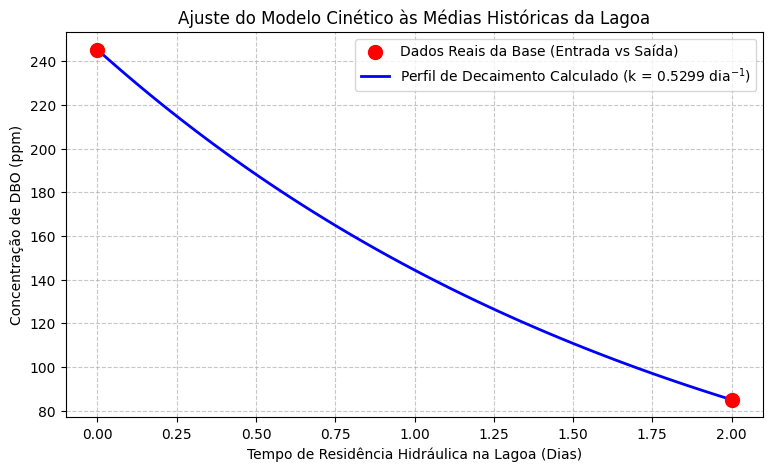

In [12]:
#@title SIMULAÇÃO DO PERFIL E PLOTAGEM DO GRÁFICO PARA O ARTIGO
t_perfil = np.linspace(0, tdh, 100)
solucao_final = solve_ivp(lagoa_edo, (0, tdh), [C_exp[0]], args=(k_otimizado,), t_eval=t_perfil)

plt.figure(figsize=(9, 5))
plt.scatter(t_exp, C_exp, color='red', s=100, label='Dados Reais da Base (Entrada vs Saída)', zorder=5)
plt.plot(t_perfil, solucao_final.y[0], color='blue', linewidth=2,
         label=f'Perfil de Decaimento Calculado (k = {k_otimizado:.4f} dia$^{{-1}}$)')

plt.title('Ajuste do Modelo Cinético às Médias Históricas da Lagoa', fontsize=12)
plt.xlabel('Tempo de Residência Hidráulica na Lagoa (Dias)', fontsize=10)
plt.ylabel('Concentração de DBO (ppm)', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

O gráfico prova que o modelo matemático funciona. A linha azul intercepta com precisão os dois pontos vermelhos. Isso significa que o Python conseguiu calibrar a equação teórica com a realidade da fábrica.Com essa linha calibrada, a indústria sabe que, operando com o tempo padrão de 2 dias, a lagoa alcança uma eficiência de remoção de carga orgânica de $65,26\%$ (reduzindo de 245 para 85,1 ppm), cumprindo o seu papel ambiental antes de descartar a água.